# Analyze Financial Portfolios with Gemini Enterprise Agent Platform Code Execution

This notebook covers **Tasks 1–4** of the lab. You create an Agent Engine, provision a Code Execution sandbox, and use it to analyze a stock portfolio, computing daily returns, annualized volatility, and Sharpe ratios, and generating a performance chart.

**Before running this notebook**, confirm that `.env` exists in this directory with your `GOOGLE_CLOUD_PROJECT` set. The init cell loads it automatically.

Run cells in order. All variables (`client`, `agent_engine`, `sandbox_resource_name`) persist in the kernel between cells. Do not restart the kernel mid-lab.

---
## Task 1: Set up the environment

Install the Agent Platform SDK and ADK, then initialize the Vertex AI client.

In [1]:
import os
import vertexai
from dotenv import load_dotenv

# Load project credentials from .env in this directory.
loaded = load_dotenv(override=True)
assert loaded, (
    "No .env file found. Complete the 'Create the environment file' step in Task 1 first."
)

PROJECT_ID = os.environ.get('GOOGLE_CLOUD_PROJECT')
assert PROJECT_ID, "GOOGLE_CLOUD_PROJECT is not set in .env. Check your .env file."

LOCATION = "us-central1"
os.environ.setdefault('GOOGLE_GENAI_USE_VERTEXAI', '1')

print('Project:', PROJECT_ID)
print('Location:', LOCATION)
print('GOOGLE_GENAI_USE_VERTEXAI:', os.environ['GOOGLE_GENAI_USE_VERTEXAI'])
print('vertexai version:', vertexai.__version__)

vertexai.init(project=PROJECT_ID, location=LOCATION)
client = vertexai.Client(project=PROJECT_ID, location=LOCATION)
print('Client initialized.')

Project: qwiklabs-gcp-02-55eb026f7836
Location: us-central1
GOOGLE_GENAI_USE_VERTEXAI: TRUE
vertexai version: 1.154.0
Client initialized.


---
## Task 2: Create an Agent Engine and Code Execution sandbox

An **Agent Engine** is the parent container that owns sandboxes. A **sandbox** is the isolated environment where your Python code runs. Both persist across cells and are referenced by all subsequent tasks.

In [2]:
# Create the Agent Engine.
agent_engine = client.agent_engines.create()
print('Agent Engine created:', agent_engine.api_resource.name)

Agent Engine created: projects/355601931302/locations/us-central1/reasoningEngines/6082227295240585216


In [3]:
from vertexai import types

# TODO: Create the Code Execution sandbox under the Agent Engine.
# Refer to the documentation to learn how to instantiate a sandbox:
# https://docs.cloud.google.com/gemini-enterprise-agent-platform/scale/sandbox/code-execution-quickstart#create_a_sandbox
#
# You will need to pass the following arguments to your method:
#  - name: agent_engine.api_resource.name
#  - config: types.CreateAgentEngineSandboxConfig(display_name='cymbal_sandbox')
#  - spec: {'code_execution_environment': {}}

sandbox_operation = client.agent_engines.sandboxes.create(
    name=agent_engine.api_resource.name,
    config=types.CreateAgentEngineSandboxConfig(display_name='cymbal_sandbox'),
    spec={'code_execution_environment': {}}
)

sandbox_resource_name = sandbox_operation.response.name
print('Sandbox created:', sandbox_resource_name)

Sandbox created: projects/355601931302/locations/us-central1/reasoningEngines/6082227295240585216/sandboxEnvironments/7894962978896740352


In [4]:
# Verify the sandbox is available.
sandbox = client.agent_engines.sandboxes.get(name=sandbox_resource_name)
print('Sandbox display name:', sandbox.display_name)

Sandbox display name: cymbal_sandbox


In [5]:
# Create a temporary sandbox, list all sandboxes, then delete the temporary one.

temp_operation = client.agent_engines.sandboxes.create(
    name=agent_engine.api_resource.name,
    config=types.CreateAgentEngineSandboxConfig(display_name='temp_sandbox'),
    spec={'code_execution_environment': {}},
)
temp_sandbox_name = temp_operation.response.name
print(f'Temporary sandbox created: {temp_sandbox_name}')

sandboxes = list(client.agent_engines.sandboxes.list(name=agent_engine.api_resource.name))
print(f'\nFound {len(sandboxes)} active sandbox(es):')
for s in sandboxes:
    print(f'  - {s.display_name}')

client.agent_engines.sandboxes.delete(name=temp_sandbox_name)
print('\nTemporary sandbox deleted.')

Temporary sandbox created: projects/355601931302/locations/us-central1/reasoningEngines/6082227295240585216/sandboxEnvironments/8660574915549724672

Found 2 active sandbox(es):
  - temp_sandbox
  - cymbal_sandbox

Temporary sandbox deleted.


### Add the sandbox resource name to .env

The cell below automatically appends your `sandbox_resource_name` to the `.env` file using a bash magic command (`!`). It then prints the contents of the file so you can verify it was added. The ADK agent reads it from there in Task 5.

In [6]:
# TODO: Copy the sandbox resource name from the cell above 
# and paste it between the quotes below.
MY_SANDBOX_NAME = "projects/355601931302/locations/us-central1/reasoningEngines/6082227295240585216/sandboxEnvironments/8660574915549724672"

# Append the sandbox resource name to the .env file
!echo "SANDBOX_RESOURCE_NAME={MY_SANDBOX_NAME}" >> .env

# Verify it was added
!cat .env

GOOGLE_GENAI_USE_VERTEXAI=TRUE
GOOGLE_CLOUD_PROJECT=qwiklabs-gcp-02-55eb026f7836
GOOGLE_CLOUD_LOCATION=global
MODEL=gemini-3.1-flash-lite
SANDBOX_RESOURCE_NAME=projects/355601931302/locations/us-central1/reasoningEngines/6082227295240585216/sandboxEnvironments/8660574915549724672


---
## Task 3: Execute Python code and read results

Send Python code to the sandbox and parse stdout. Then upload a CSV file with portfolio price data and load it inside the sandbox.

In [7]:
# Run a simple calculation
import json


input_data = {'code': "result = 252 ** 0.5\nprint(f'Annualization factor: {result:.4f}')"}

# TODO: Execute code in the sandbox using the execute_code method.
# Refer to the documentation to learn how to execute code:
# https://docs.cloud.google.com/gemini-enterprise-agent-platform/scale/sandbox/code-execution-quickstart#execute_code_in_a_sandbox
#
# You will need to pass the following arguments to your method:
# - name: sandbox_resource_name
# - input_data: code to execute

response = client.agent_engines.sandboxes.execute_code(
   name = sandbox_resource_name,
   input_data = input_data
)


for output in response.outputs:
    if output.mime_type == 'application/json' and output.metadata is None:
        result = json.loads(output.data.decode('utf-8'))
        print('Stdout:', result.get('msg_out'))
        if result.get('msg_err'):
            print('Stderr:', result.get('msg_err'))

Stdout: Annualization factor: 15.8745



In [8]:
# Prepare the portfolio CSV with historical price data.
csv_content = """date,GOOGL,MSFT,AMZN
2024-01-02,140.93,374.02,153.42
2024-01-03,138.21,370.87,151.94
2024-01-04,139.01,373.36,152.81
2024-01-05,141.84,375.80,155.67
2024-01-08,142.73,378.91,157.32
2024-01-09,143.29,377.50,156.88
2024-01-10,144.11,380.44,158.23
2024-01-11,143.67,379.22,157.95
2024-01-12,145.02,382.01,159.44
2024-01-15,146.33,384.50,161.02
"""
csv_bytes = csv_content.encode('utf-8')

# Upload the CSV and load it with Pandas inside the sandbox.
# The df variable is now in sandbox memory and persists for all subsequent calls.
load_code = """
import pandas as pd
import io

df = pd.read_csv(io.BytesIO(open('portfolio.csv', 'rb').read()))
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
print(f'Loaded {len(df)} rows, columns: {list(df.columns)}')
print(df.head())
"""

response = client.agent_engines.sandboxes.execute_code(
    name=sandbox_resource_name,
    input_data={
        'code': load_code,
        'files': [{'name': 'portfolio.csv', 'content': csv_bytes}],
    },
)

for output in response.outputs:
    if output.mime_type == 'application/json' and output.metadata is None:
        result = json.loads(output.data.decode('utf-8'))
        print(result.get('msg_out'))

Loaded 10 rows, columns: ['GOOGL', 'MSFT', 'AMZN']
             GOOGL    MSFT    AMZN
date                              
2024-01-02  140.93  374.02  153.42
2024-01-03  138.21  370.87  151.94
2024-01-04  139.01  373.36  152.81
2024-01-05  141.84  375.80  155.67
2024-01-08  142.73  378.91  157.32



---
## Task 4: Compute risk metrics and generate a chart

The sandbox retains `df` from Task 3. You compute daily returns, annualized volatility, and the Sharpe ratio across calls, then generate a matplotlib performance chart and retrieve the PNG bytes.

> **Note your Sharpe ratio results.** In Task 5 you send the same calculation to the ADK agent and compare the numbers.

In [9]:
# Compute daily returns and annualized volatility.
# df is already in scope inside the sandbox from Task 3.
metrics_code = """
import numpy as np

returns = df.pct_change().dropna()
annualized_vol = returns.std() * (252 ** 0.5)
annualized_return = returns.mean() * 252

print('=== Cymbal Analytics - Portfolio Metrics ===')
print('Annualized Return:')
for ticker, val in annualized_return.items():
    print(f'  {ticker}: {val:.2%}')
print('Annualized Volatility:')
for ticker, val in annualized_vol.items():
    print(f'  {ticker}: {val:.2%}')
"""

response = client.agent_engines.sandboxes.execute_code(
    name=sandbox_resource_name,
    input_data={'code': metrics_code},
)

for output in response.outputs:
    if output.mime_type == 'application/json' and output.metadata is None:
        result = json.loads(output.data.decode('utf-8'))
        print(result.get('msg_out'))

=== Cymbal Analytics - Portfolio Metrics ===
Annualized Return:
  GOOGL: 106.80%
  MSFT: 77.95%
  AMZN: 136.57%
Annualized Volatility:
  GOOGL: 17.07%
  MSFT: 10.08%
  AMZN: 13.71%



In [10]:
# Compute the Sharpe ratio for each position.
# Note: annualized_return and annualized_vol are in scope from the previous call.

sharpe_code = """
risk_free_rate = 0.045

# TODO: Calculate the Sharpe ratio using the variables defined in the previous cell.
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol

print('=== Sharpe Ratios ===')
for ticker, val in sharpe_ratio.items():
    print(f'  {ticker}: {val:.4f}')

best = sharpe_ratio.idxmax()
print(f'Best risk-adjusted position: {best} (Sharpe: {sharpe_ratio[best]:.4f})')
"""

response = client.agent_engines.sandboxes.execute_code(
    name=sandbox_resource_name,
    input_data={'code': sharpe_code},
)

for output in response.outputs:
    if output.mime_type == 'application/json' and output.metadata is None:
        result = json.loads(output.data.decode('utf-8'))
        print(result.get('msg_out'))
        if result.get('msg_err'):
            print('Stderr:', result.get('msg_err'))

=== Sharpe Ratios ===
  GOOGL: 5.9914
  MSFT: 7.2872
  AMZN: 9.6365
Best risk-adjusted position: AMZN (Sharpe: 9.6365)



Chart saved: portfolio_performance.png

Received file: portfolio_performance.png (104680 bytes)
Chart written to portfolio_performance.png

--- Chart Preview ---


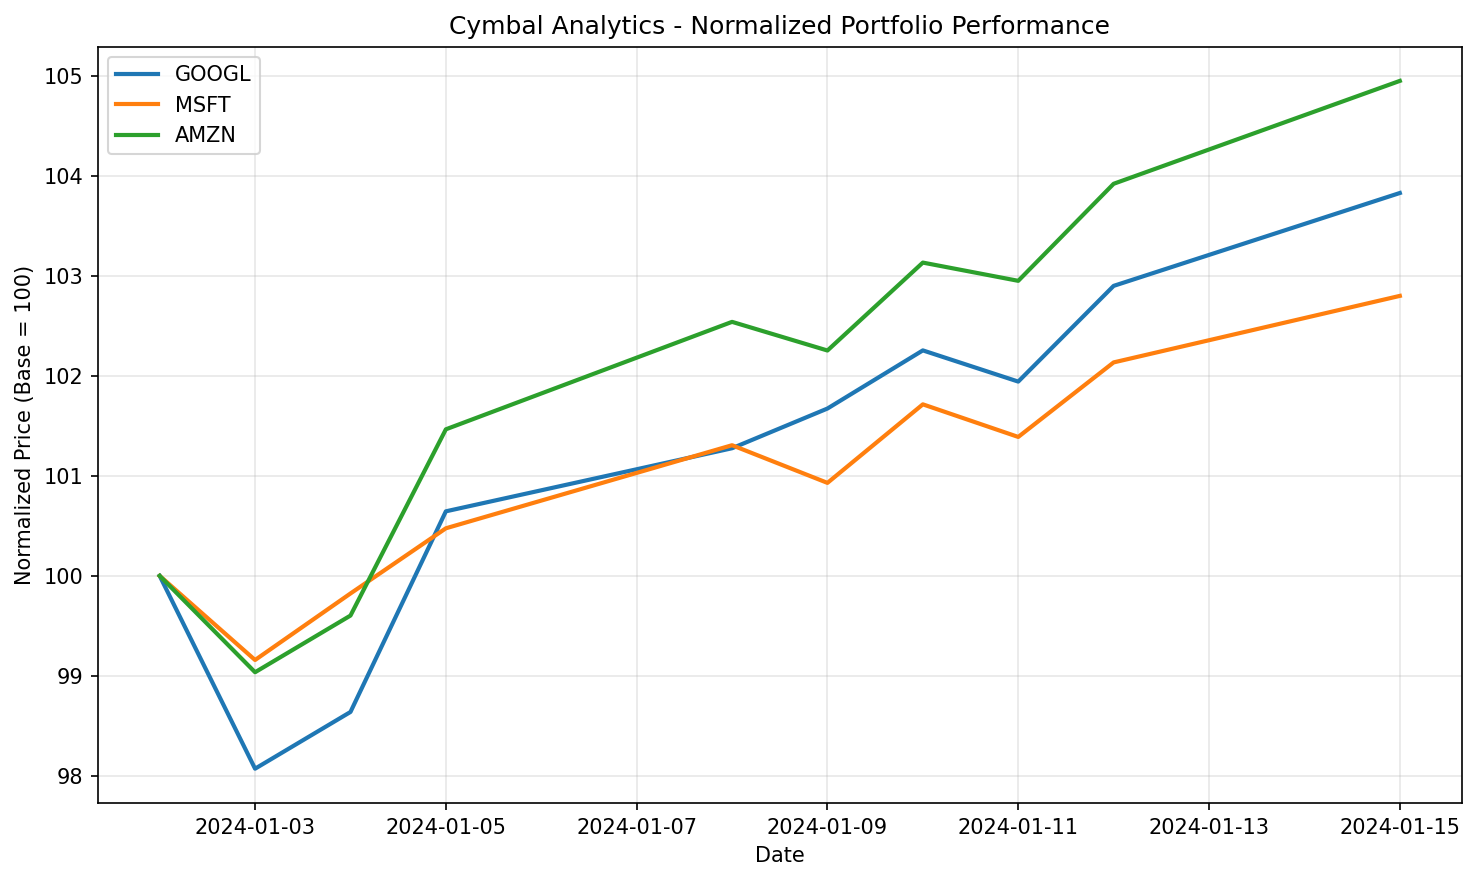

In [11]:
# Generate a normalized performance chart and retrieve the PNG bytes.
chart_code = """
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

normalized = (df / df.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(10, 6))
for ticker in normalized.columns:
    ax.plot(normalized.index, normalized[ticker], label=ticker, linewidth=2)

ax.set_title('Cymbal Analytics - Normalized Portfolio Performance')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price (Base = 100)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('portfolio_performance.png', dpi=150, bbox_inches='tight')
print('Chart saved: portfolio_performance.png')
"""

response = client.agent_engines.sandboxes.execute_code(
    name=sandbox_resource_name,
    input_data={'code': chart_code},
)

chart_bytes = None
for output in response.outputs:
    if output.mime_type == 'application/json' and output.metadata is None:
        result = json.loads(output.data.decode('utf-8'))
        print(result.get('msg_out'))
    elif output.metadata and output.metadata.attributes:
        file_name = output.metadata.attributes.get('file_name')
        if isinstance(file_name, bytes):
            file_name = file_name.decode('utf-8')
        chart_bytes = output.data
        print(f'Received file: {file_name} ({len(chart_bytes)} bytes)')

from IPython.display import Image, display

if chart_bytes:
    # Save the file locally as before
    with open('portfolio_performance.png', 'wb') as f:
        f.write(chart_bytes)
    print('Chart written to portfolio_performance.png')
    
    # Display the image directly in the notebook output
    print('\n--- Chart Preview ---')
    display(Image(data=chart_bytes))

---
## Task 6: Clean up resources

Return here after completing Task 5 in the lab guide. Run this cell to delete the sandbox and Agent Engine and avoid ongoing charges.

> **Note:** `agent_engine.delete(force=True)` cascades to all sandboxes under the engine. This lab deletes the sandbox explicitly first to demonstrate each API call individually.

In [ ]:
# Delete the sandbox.
client.agent_engines.sandboxes.delete(name=sandbox_resource_name)
print('Sandbox deleted.')

# Delete the Agent Engine (cascades to any remaining sandboxes).
agent_engine.delete(force=True)
print('Agent Engine deleted.')

# Verify cleanup.
try:
    remaining = list(client.agent_engines.sandboxes.list(name=agent_engine.api_resource.name))
    print(f'Remaining sandboxes: {len(remaining)}')
except Exception as e:
    print(f'Agent Engine deleted (expected): {type(e).__name__}')